### Import bibliotek i konfiguracja

In [23]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import skfuzzy as fuzz
import skfuzzy.control as ctrl


RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

ADOPTION_SPEED_LABELS = {
    0: '0–7',
    1: '8–30',
    2: '31–90',
    3: '>100',
}
CLASS_ORDER = sorted(ADOPTION_SPEED_LABELS.keys())
CLASS_NAMES = [ADOPTION_SPEED_LABELS[c] for c in CLASS_ORDER]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Wczytanie danych i modeli

In [24]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = Path('../models')
INPUT_PATH = f'{PROCESSED_DIR}/train_clean_anomaly.csv'

df = pd.read_csv(INPUT_PATH)
if 'is_anomaly' in df.columns:
    df = df.drop(columns=['is_anomaly'])

y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])

rf_model = joblib.load(MODELS_DIR / 'rf_best.pkl')
svm_model = joblib.load(MODELS_DIR / 'svm_best.pkl')
knn_model = joblib.load(MODELS_DIR / 'knn_best.pkl')
nn_model = joblib.load(MODELS_DIR / 'nn_best.pkl')
feature_names = joblib.load(MODELS_DIR / 'feature_names.pkl')

X = X[feature_names]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

# RF -> dane nieskalowane, pozostale -> skalowane
rf_pred = rf_model.predict(X_test).astype(int)
svm_pred = svm_model.predict(X_test_scaled).astype(int)
knn_pred = knn_model.predict(X_test_scaled).astype(int)
nn_pred = nn_model.predict(X_test_scaled).astype(int)

base_acc = {
    'Random Forest': accuracy_score(y_test, rf_pred),
    'SVM': accuracy_score(y_test, svm_pred),
    'KNN': accuracy_score(y_test, knn_pred),
    'MLP': accuracy_score(y_test, nn_pred),
}

print('\nAccuracy pojedynczych modeli (punkt startowy):')
display(pd.DataFrame({'accuracy': base_acc}).round(4))

X_train: (11875, 20), X_test: (2969, 20)

Accuracy pojedynczych modeli (punkt startowy):


,accuracy
Random Forest,0.4160
SVM,0.3907
KNN,0.3654
MLP,0.4015


### Przygotowanie wejść

In [25]:
# Wagi modeli na podstawie accuracy
acc_list = np.array([base_acc['Random Forest'], base_acc['SVM'], base_acc['KNN'], base_acc['MLP']])
weights = acc_list / acc_list.sum()

print('Wagi modeli:')
display(pd.DataFrame({'Model': ['RF', 'SVM', 'KNN', 'MLP'], 'Accuracy': acc_list, 'Waga': weights}).round(4))

preds_matrix = np.vstack([rf_pred, svm_pred, knn_pred, nn_pred]).T  # (n, 4) glosy modeli


def policz_poparcia(glosy):
    """Dla wiersza 4 glosow zwraca wektor poparcia 4 klas (wazony accuracy)."""
    s = np.zeros(4)
    for model_idx, klasa in enumerate(glosy):
        s[klasa] += weights[model_idx]
    return s


supports = np.array([policz_poparcia(row) for row in preds_matrix])
supports_df = pd.DataFrame(supports, columns=['sup0', 'sup1', 'sup2', 'sup3'])

print('\nPoparcia klas (wejścia systemu rozmytego):')
display(supports_df.head())

Wagi modeli:


,Model,Accuracy,Waga
0,RF,0.4160,0.2643
1,SVM,0.3907,0.2483
2,KNN,0.3654,0.2322
3,MLP,0.4015,0.2551



Poparcia klas (wejścia systemu rozmytego):


,sup0,sup1,sup2,sup3
0,0.255137,0.744863,0.000000,0.000000
1,0.000000,1.000000,0.000000,0.000000
2,0.496575,0.503425,0.000000,0.000000
3,0.000000,0.000000,0.264341,0.735659
4,0.503425,0.000000,0.000000,0.496575


### Definicja zmiennych wejściowych i wyjściowych oraz funkcji przynależności

In [26]:
# Wejscie: poparcie kazdej klasy w zakresie [0, 1]
uni_sup = np.arange(0, 1.001, 0.01)
sup_inputs = {}
for c in range(4):
    var = ctrl.Antecedent(uni_sup, f'sup{c}')
    var['niskie'] = fuzz.trimf(var.universe, [0.0, 0.0, 0.6])
    var['wysokie'] = fuzz.trimf(var.universe, [0.2, 1.0, 1.0])
    sup_inputs[c] = var

# Wyjscie: przewidywana klasa w zakresie [0, 3]
uni_out = np.arange(0, 3.01, 0.01)
klasa = ctrl.Consequent(uni_out, 'klasa')
klasa['k0'] = fuzz.trimf(uni_out, [0, 0, 1])
klasa['k1'] = fuzz.trimf(uni_out, [0, 1, 2])
klasa['k2'] = fuzz.trimf(uni_out, [1, 2, 3])
klasa['k3'] = fuzz.trimf(uni_out, [2, 3, 3])

# Defuzyfikacja MOM (mean of maximum) — wybiera klase o najwiekszym poparciu
klasa.defuzzify_method = 'mom'

print('Zmienne lingwistyczne zdefiniowane (defuzyfikacja: mom).')

Zmienne lingwistyczne zdefiniowane (defuzyfikacja: mom).


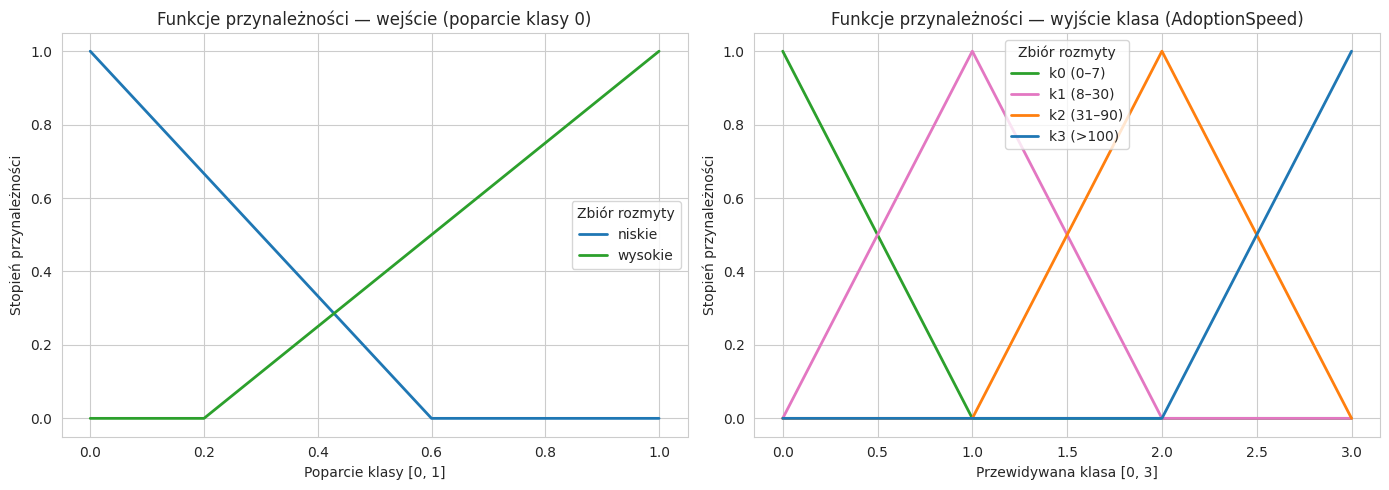

In [27]:
# Wizualizacja: wejscie oraz wyjscie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nazwa, kolor in [('niskie', 'tab:blue'), ('wysokie', 'tab:green')]:
    axes[0].plot(sup_inputs[0].universe, sup_inputs[0][nazwa].mf, label=nazwa, color=kolor, linewidth=2)
axes[0].set_title('Funkcje przynależności — wejście (poparcie klasy 0)')
axes[0].set_xlabel('Poparcie klasy [0, 1]')
axes[0].set_ylabel('Stopień przynależności')
axes[0].legend(title='Zbiór rozmyty')

kolory_out = ['tab:green', 'tab:pink', 'tab:orange', 'tab:blue']
for c in range(4):
    axes[1].plot(klasa.universe, klasa[f'k{c}'].mf, label=f'k{c} ({CLASS_NAMES[c]})', color=kolory_out[c], linewidth=2)
axes[1].set_title('Funkcje przynależności — wyjście klasa (AdoptionSpeed)')
axes[1].set_xlabel('Przewidywana klasa [0, 3]')
axes[1].set_ylabel('Stopień przynależności')
axes[1].legend(title='Zbiór rozmyty')

plt.tight_layout()
plt.show()

### Baza reguł

In [28]:
# Wysokie poparcie klasy c = klasa c
reguly = [ctrl.Rule(sup_inputs[c]['wysokie'], klasa[f'k{c}']) for c in range(4)]

# Reguly pomocnicze 
reguly.append(ctrl.Rule(sup_inputs[0]['wysokie'] & sup_inputs[1]['niskie'], klasa['k0']))
reguly.append(ctrl.Rule(sup_inputs[3]['wysokie'] & sup_inputs[2]['niskie'], klasa['k3']))

adoption_ctrl = ctrl.ControlSystem(reguly)
sim = ctrl.ControlSystemSimulation(adoption_ctrl)

print(f'Zdefiniowano {len(reguly)} reguł rozmytych.')

Zdefiniowano 6 reguł rozmytych.


### Testowanie systemu

In [29]:
cache = {}
fuzzy_class = []
brak_reguly = 0

for i in range(len(preds_matrix)):
    klucz = tuple(preds_matrix[i])
    if klucz not in cache:
        s = policz_poparcia(klucz)
        for c in range(4):
            sim.input[f'sup{c}'] = float(s[c])
        try:
            sim.compute()
            cache[klucz] = int(np.clip(round(sim.output['klasa']), 0, 3))
        except KeyError:
            cache[klucz] = int(np.argmax(s))
            brak_reguly += 1
    fuzzy_class.append(cache[klucz])

fuzzy_class = np.array(fuzzy_class)

wyniki = pd.DataFrame({
    'rf_pred': rf_pred,
    'svm_pred': svm_pred,
    'knn_pred': knn_pred,
    'nn_pred': nn_pred,
    'fuzzy_class': fuzzy_class,
    'prawdziwa_klasa': y_test.values,
})

print('\nPierwsze 10 wyników:')
display(wyniki.head(10))


Pierwsze 10 wyników:


,rf_pred,svm_pred,knn_pred,nn_pred,fuzzy_class,prawdziwa_klasa
0,1,1,1,0,1,1
1,1,1,1,1,1,2
2,0,1,0,1,1,3
3,2,3,3,3,3,2
4,3,0,3,0,0,0
5,3,3,3,1,3,3
6,3,3,0,3,3,3
7,0,0,0,3,0,3
8,3,3,3,1,3,1
9,2,2,2,2,2,1


### Wizualizacja

Rekord 0: głosy=[np.int64(1), np.int64(1), np.int64(1), np.int64(0)], poparcia=[0.255 0.745 0.    0.   ]
Defuzyfikacja = 1.00  ->  klasa 1 (8–30)


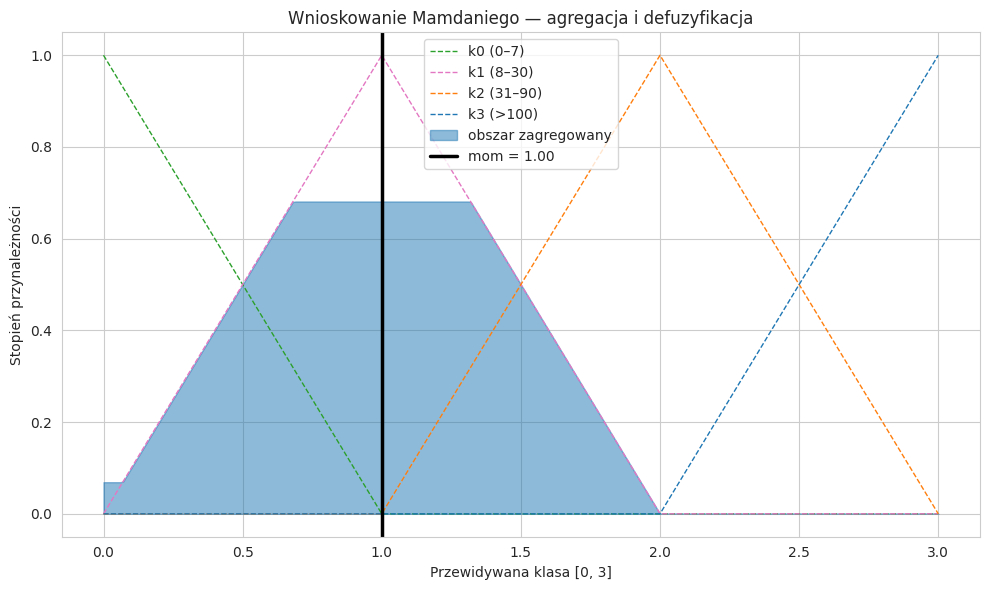

In [30]:
idx = 0
glosy = preds_matrix[idx]
s = policz_poparcia(glosy)
print(f'Rekord {idx}: głosy={list(glosy)}, poparcia={s.round(3)}')


def stopien(var, zbior, x):
    return fuzz.interp_membership(var.universe, var[zbior].mf, x)

# Aktywacja zbiorow wyjsciowych
akt = {c: stopien(sup_inputs[c], 'wysokie', s[c]) for c in range(4)}
akt[0] = max(akt[0], min(stopien(sup_inputs[0], 'wysokie', s[0]), stopien(sup_inputs[1], 'niskie', s[1])))
akt[3] = max(akt[3], min(stopien(sup_inputs[3], 'wysokie', s[3]), stopien(sup_inputs[2], 'niskie', s[2])))

obciete = {c: np.fmin(akt[c], klasa[f'k{c}'].mf) for c in range(4)}
agg = np.fmax.reduce(list(obciete.values()))

wynik = fuzz.defuzz(klasa.universe, agg, 'mom')
print(f'Defuzyfikacja = {wynik:.2f}  ->  klasa {int(np.clip(round(wynik), 0, 3))} ({CLASS_NAMES[int(np.clip(round(wynik), 0, 3))]})')

plt.figure(figsize=(10, 6))
for c in range(4):
    plt.plot(klasa.universe, klasa[f'k{c}'].mf, color=kolory_out[c], linewidth=1, linestyle='--',
             label=f'k{c} ({CLASS_NAMES[c]})')
plt.fill_between(klasa.universe, 0, agg, color='tab:blue', alpha=0.5, label='obszar zagregowany')
plt.axvline(wynik, color='black', linewidth=2.5, label=f'mom = {wynik:.2f}')
plt.title('Wnioskowanie Mamdaniego — agregacja i defuzyfikacja')
plt.xlabel('Przewidywana klasa [0, 3]')
plt.ylabel('Stopień przynależności')
plt.legend()
plt.tight_layout()
plt.show()

### Ocena logiki rozmytej

Porównanie wszystkich metod z projektu:


,Accuracy
RF,0.4160
SVM,0.3907
KNN,0.3654
MLP,0.4015
Hard Voting,0.4143
Weighted Voting,0.4153
Fuzzy System,0.4153


Classification report — Fuzzy System
              precision    recall  f1-score   support

         0–7       0.41      0.39      0.40       695
        8–30       0.35      0.37      0.36       798
       31–90       0.36      0.17      0.23       642
        >100       0.48      0.67      0.56       834

    accuracy                           0.42      2969
   macro avg       0.40      0.40      0.39      2969
weighted avg       0.40      0.42      0.40      2969



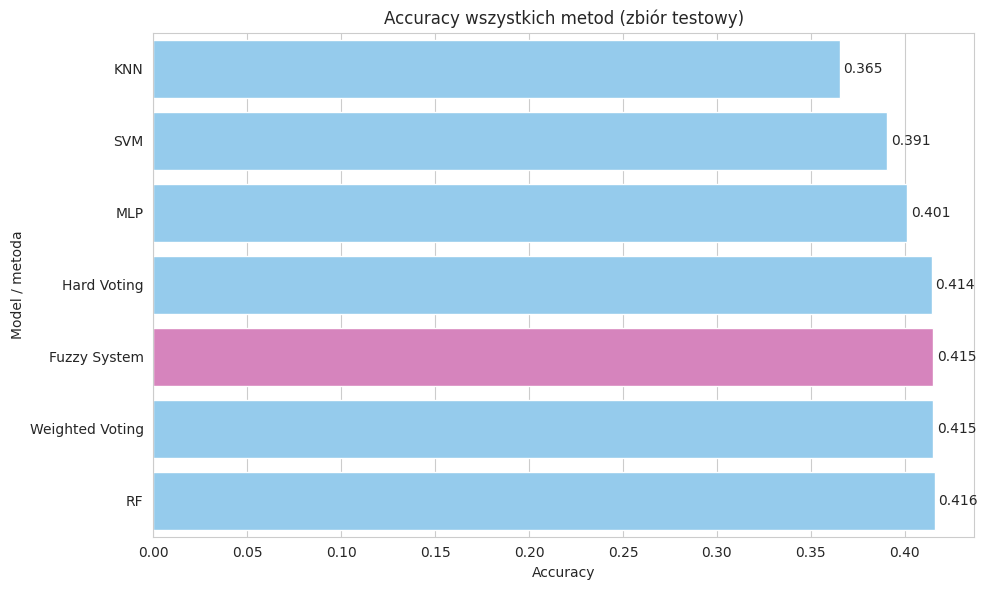

In [33]:
acc_fuzzy = accuracy_score(y_test, fuzzy_class)

hard_vote = np.array([np.bincount(row, minlength=4).argmax() for row in preds_matrix])
weighted_vote = np.array([np.bincount(row, weights=weights, minlength=4).argmax() for row in preds_matrix])
acc_hard = accuracy_score(y_test, hard_vote)
acc_weighted = accuracy_score(y_test, weighted_vote)

porownanie = pd.DataFrame({
    'Accuracy': [
        base_acc['Random Forest'],
        base_acc['SVM'],
        base_acc['KNN'],
        base_acc['MLP'],
        acc_hard,
        acc_weighted,
        acc_fuzzy,
    ],
}, index=['RF', 'SVM', 'KNN', 'MLP', 'Hard Voting', 'Weighted Voting', 'Fuzzy System'])

print('Porównanie wszystkich metod z projektu:')
display(porownanie.round(4))

print('Classification report — Fuzzy System')
print(classification_report(y_test, fuzzy_class, target_names=CLASS_NAMES, zero_division=0))

uporzadkowane = porownanie['Accuracy'].sort_values()
kolory = ['tab:pink' if 'Fuzzy' in idx else 'lightskyblue' for idx in uporzadkowane.index]
plt.figure(figsize=(10, 6))
sns.barplot(x=uporzadkowane.values, y=uporzadkowane.index,
            hue=uporzadkowane.index, palette=kolory, legend=False)
for i, v in enumerate(uporzadkowane.values):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.title('Accuracy wszystkich metod (zbiór testowy)')
plt.xlabel('Accuracy')
plt.ylabel('Model / metoda')
plt.tight_layout()
plt.show()